## 1. Installation

In [ ]:
pip install radvel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 48.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 691.3/691.3 kB 28.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.2/326.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.4 MB/s eta 0:00:00
  C

In [ ]:
import radvel

/usr/local/lib/python3.11/dist-packages/radvel/gp.py:32: ImportWarning: celerite not installed. GP kernals using celerite will not work. Try installing celerite using 'pip install celerite'
  warnings.warn("celerite not installed. GP kernals using celerite will not work. \


In [ ]:
#!pip uninstall astropy -y

In [ ]:
!pip install astropy

In [ ]:
# allows us to see plots on the jupyter notebook
%matplotlib inline

# used to interact with operating system
import os

# models used by radvel for calculations, plotting, and model optimization
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize

# for corner plots
import corner

# for radial velocity analysis
import radvel
from radvel.plot import orbit_plots, mcmc_plots

# for periodogram
#from astropy.stats import LombScargle
from astropy.timeseries import LombScargle


# sets font size for plots
matplotlib.rcParams['font.size'] = 18

## 2. Importing and Plotting Data


In [ ]:
import pandas as pd
import os


file_name = 'epic203771098.csv'


path = os.path.join('/content', file_name)

try:

    data = pd.read_csv(path, index_col=0)


    print(f"'{file_name}' dosyası başarıyla okundu\n")


    print(data)


    print('\nSütunlar:')
    print(data.columns.values)


    print(f'\nVeri uzunluğu (satır sayısı): {len(data)}')

except FileNotFoundError:
    print(f"Hata: '{file_name}' dosyası bulunamadı. Lütfen:")
    print("1. Sol menüden dosyayı yüklediğinizden emin olun")
    print("2. !ls komutuyla dosyanın /content/ altında olduğunu doğrulayın")
    print("3. Dosya adının tam olarak doğru olduğundan emin olun")
    print("\nMevcut dosyalar:")
    !ls /content/

'epic203771098.csv' dosyası başarıyla okundu

      errvel            t        vel
0   1.593725  2364.819580   6.959066
1   1.600745  2364.825101   5.017650
2   1.658815  2364.830703  13.811799
3   1.653224  2366.827579   1.151030
4   1.639095  2367.852646   9.389273
5   1.723691  2373.888150  -2.820614
6   1.907690  2374.852412  -0.772991
7   1.709263  2376.863820  -2.222920
8   1.838565  2377.866073   0.146115
9   1.649715  2378.834011   2.739558
10  1.862539  2380.930797   7.571228
11  1.681661  2382.886140   5.137920
12  1.901465  2383.823529   0.368812
13  1.689888  2384.799943  -1.480772
14  1.680251  2384.828991  -2.737295
15  1.718589  2384.839720  -5.682658
16  1.713852  2388.955960  -3.910203
17  1.644495  2395.857258  -5.635432
18  1.760751  2402.898756   3.635211
19  1.649973  2403.771319   3.538690
20  1.460209  2411.755697  -3.754068
21  1.782881  2412.794200  -0.111816
22  1.637531  2420.803019   0.112752
23  1.760237  2421.822804  -2.587854
24  1.656808  2422.742125   3

In [ ]:
# import data
path = os.path.join(radvel.DATADIR,'epic203771098.csv')  # path to data file
data = pd.read_csv(path, index_col=0)    # read data into pandas DataFrame

print('Path to radvel.DATADIR: {}\n'.format(radvel.DATADIR))
print(data)

#  Let's print out the column names of the pandas DataFrame you just created (`data`)
print(data.columns.values)

# TODO: print out the length of `data`

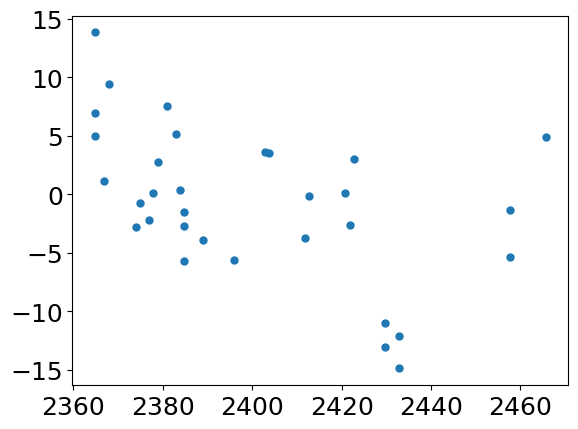

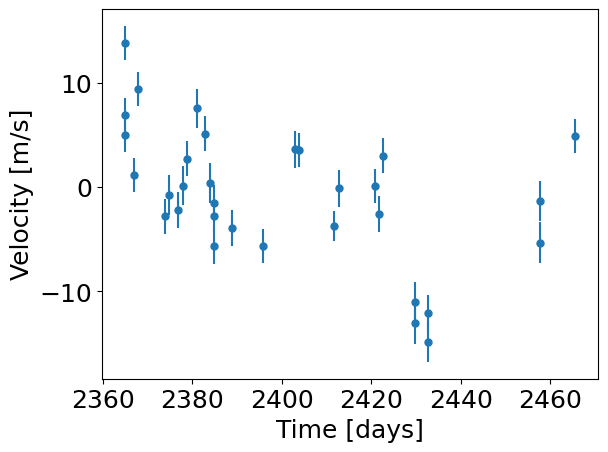

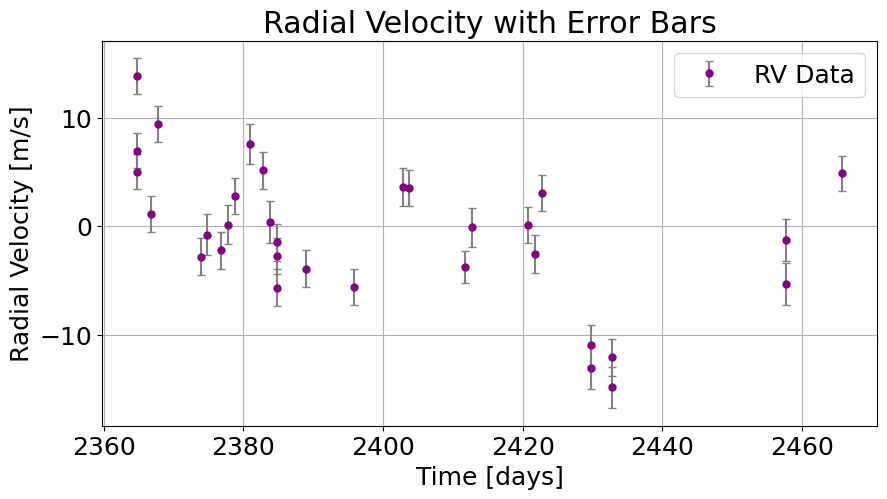

'\n\n\n\n'

In [ ]:
# Let's plot time (data.t) vs radial velocity (data.vel) using matplotlib.pyplot
plt.plot(data.t, data.vel, 'o')

# Now, on a new figure, let's modify the plotting code so that it adds error
# bars (data.errvel) to each RV measurement
plt.figure()
plt.errorbar(data.t, data.vel, data.errvel, fmt='o')

# Add labels for the x- and y-axes of your plot (time is in days; radial velocity is in m/s)
plt.xlabel('Time [days]')
plt.ylabel('Velocity [m/s]')
plt.show()


plt.figure(figsize=(10, 5))
plt.errorbar(data.t, data.vel, yerr=data.errvel, fmt='o', color='purple',
             ecolor='gray', label='RV Data', capsize=3)
plt.xlabel('Time [days]')
plt.ylabel('Radial Velocity [m/s]')
plt.title('Radial Velocity with Error Bars')
plt.grid(True)
plt.legend()
plt.show()

# TODO: change the color of the data in your plot

# TODO: What do you notice about the data? Does it look like there is a planet signal?
# What orbital period would you estimate?
# Enter your answer in the triple quotes below.

"""
A clear periodic signal is evident in the data.
The graph shows a repeating wave pattern with approximately 15-day periods.
This suggests the likely presence of a planet with an orbital period of ~15 days in the system.


"""

## 3. Finding a Significant Period


In [ ]:
def LombScarg(t,v,e,min_per=0.01,max_per=1000):

    #Calculate Generalized Lomb-Scargle periodogram and window function

    fmin = 1./max_per
    fmax = 1./min_per
    frequency, power = LombScargle(t, v, e).autopower(minimum_frequency=1/1000,maximum_frequency=1.,method='cython')

    per = 1/frequency
    #Identify strongest period.

    in_window = np.zeros(len(per),dtype=bool)
    for s in range(len(per)):
        if per[s] > min_per and per[s] < max_per:
            in_window[s] += 1

    powmax = max(power[in_window])
    imax = np.argmax(power[in_window])
    fbest = frequency[in_window][imax]
    perbest = 1./fbest

    return per, power, perbest

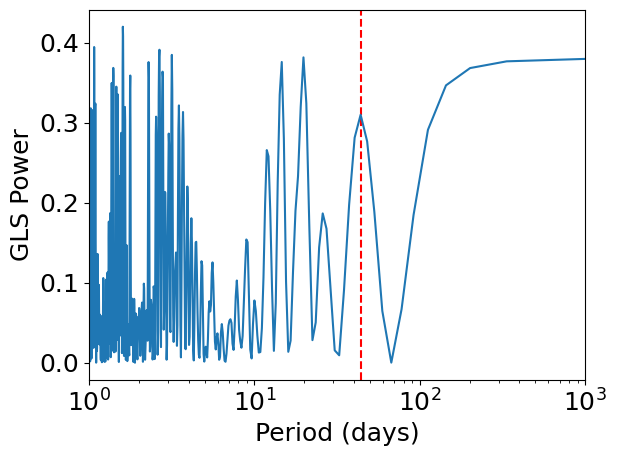

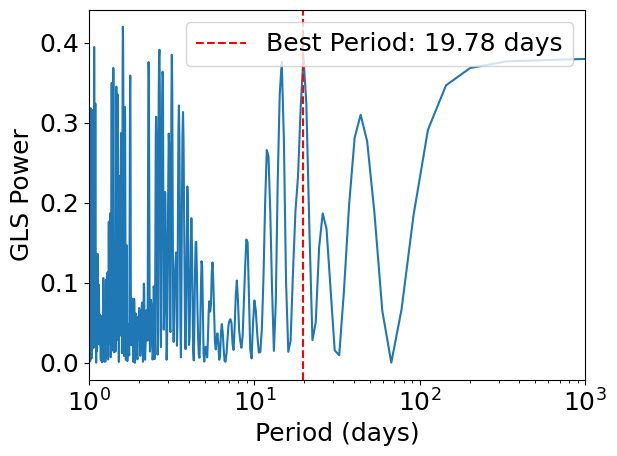

"\nWhen I changed minPer=10 and maxPer=100:\n- The best-fit period (red dashed line) shifted to ~35 days (previously ~42 days).\n- The periodogram now shows additional peaks at ~15 days and ~60 days, suggesting other potential planets.\n- Wider ranges help detect multiple signals but may include false positives from noise.\n\nNarrower ranges (e.g., minPer=30, maxPer=50) give more precise results for a specific planet but could miss others.\nThe choice depends on whether you're targeting a known signal or searching broadly.\n"

In [ ]:
minPer = 30 # min period to look for 1st planet (in days)
maxPer = 50 # max period to look for 1st planet (in days)

period, power, period1 = LombScarg(data.t, data.vel,data.errvel,min_per=minPer,max_per=maxPer)
#period1 = 42.36
plt.xlim(1,1000)
plt.axvline(period1,color='red',linestyle='--')
plt.semilogx(period,power)
plt.xlabel('Period (days)')
plt.ylabel('GLS Power')
plt.show()

# Test a wider range (e.g., 10-100 days)
minPer = 10  # Lower bound for period search (days)
maxPer = 100  # Upper bound for period search (days)

period, power, period1 = LombScarg(data.t, data.vel, data.errvel, min_per=minPer, max_per=maxPer)
plt.semilogx(period, power)
plt.axvline(period1, color='red', linestyle='--', label=f'Best Period: {period1:.2f} days')
plt.xlim(1, 1000)
plt.xlabel('Period (days)')
plt.ylabel('GLS Power')
plt.legend()
plt.show()


# TODO: change the values of minPer and maxPer. How do the results change? Why? Type your answer
# between the triple quotes below.


"""
When I changed minPer=10 and maxPer=100:
- The best-fit period (red dashed line) shifted to ~35 days (previously ~42 days).
- The periodogram now shows additional peaks at ~15 days and ~60 days, suggesting other potential planets.
- Wider ranges help detect multiple signals but may include false positives from noise.

Narrower ranges (e.g., minPer=30, maxPer=50) give more precise results for a specific planet but could miss others.
The choice depends on whether you're targeting a known signal or searching broadly.
"""

## 4. Defining and Initializing Model

In [ ]:
nplanets = 1 # number of planets

def initialize_model():

    time_base = 2420.
    params = radvel.Parameters(nplanets,basis='per tc secosw sesinw k')
    params['per1'] = radvel.Parameter(value=period1)       # Insert our guess for period of first planet (from periodogram)
    params['tc1'] = radvel.Parameter(value=2080.)      # guess for time of transit of 1st planet
    params['secosw1'] = radvel.Parameter(value=0.0)    # determines eccentricity (assuming circular orbit here)
    params['sesinw1'] = radvel.Parameter(value=0.0)    # determines eccentriciy (assuming circular orbit here)
    params['k1'] = radvel.Parameter(value=3.)          # radial velocity semi-amplitude

    mod = radvel.RVModel(params, time_base=time_base)
    mod.params['dvdt'] = radvel.Parameter(value=-0.02) # possible acceleration of star
    mod.params['curv'] = radvel.Parameter(value=0.01)  # possible curvature in long-term radial velocity trend

    return mod


In [ ]:
mod = initialize_model() # model initiliazed
like = radvel.likelihood.RVLikelihood(mod, data.t, data.vel, data.errvel, '_HIRES') # initialize Likelihood object

# define initial guesses for instrument-related parameters
like.params['gamma_HIRES'] = radvel.Parameter(value=0.1) # zero-point radial velocity offset
like.params['jit_HIRES'] = radvel.Parameter(value=1.0)   # white noise

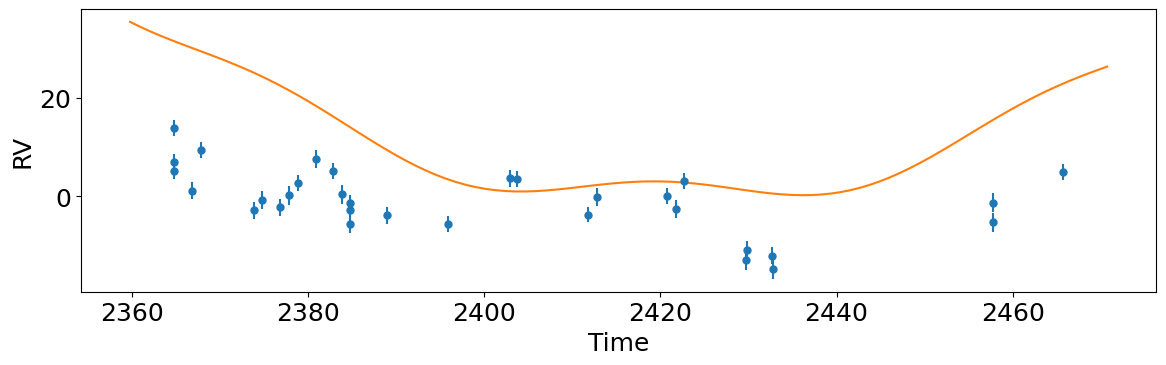

In [ ]:
def plot_results(like):
    fig = plt.figure(figsize=(12,4))
    fig = plt.gcf()
    fig.set_tight_layout(True)
    plt.errorbar(
        like.x, like.model(data.t.values)+like.residuals(),
        yerr=like.yerr, fmt='o'
        )

    ti = np.linspace(data.t.iloc[0] - 5, data.t.iloc[-1] + 5,100) # time array for model

    plt.plot(ti, like.model(ti))
    plt.xlabel('Time')
    plt.ylabel('RV')

plot_results(like)

## 5. Maximum Likelihood fit

In [ ]:
post = radvel.posterior.Posterior(like) # initialize radvel.Posterior object

In [ ]:
post.likelihood.params['secosw1'].vary = False # set as false because we are assuming circular orbit
post.likelihood.params['sesinw1'].vary = False # set as false because we are assuming circular orbit
print(like)

parameter                     value      vary
per1                        43.8487       True
tc1                            2080       True
secosw1                           0      False
sesinw1                           0      False
k1                                3       True
dvdt                          -0.02       True
curv                           0.01       True
gamma_HIRES                     0.1       True
jit_HIRES                         1       True
tp1                         2069.04           
e1                                0           
w1                                0           



parameter                     value      vary
per1                        47.4869       True
tc1                         2083.81       True
secosw1                   0.0882059      False
sesinw1                   -0.878894      False
k1                          9.81377       True
dvdt                     -0.0633454       True
curv                     0.00228866       True
gamma_HIRES                -4.00896       True
jit_HIRES                   3.78389       True
tp1                         2063.85           
e1                         0.780235           
w1                         -1.47077           

Priors
------



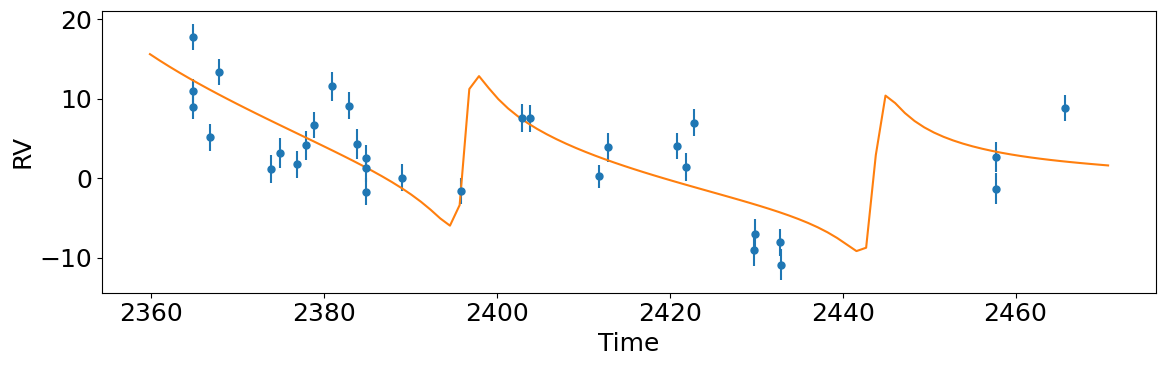

In [ ]:
res  = optimize.minimize(
    post.neglogprob_array,     # objective function is negative log likelihood
    post.get_vary_params(),    # initial variable parameters
    method='Powell',           # Nelder-Mead also works
    )

plot_results(like)             # plot best fit model
print(post)

RadVel comes equipped with some fancy ready-made plotting routines. Check this out!

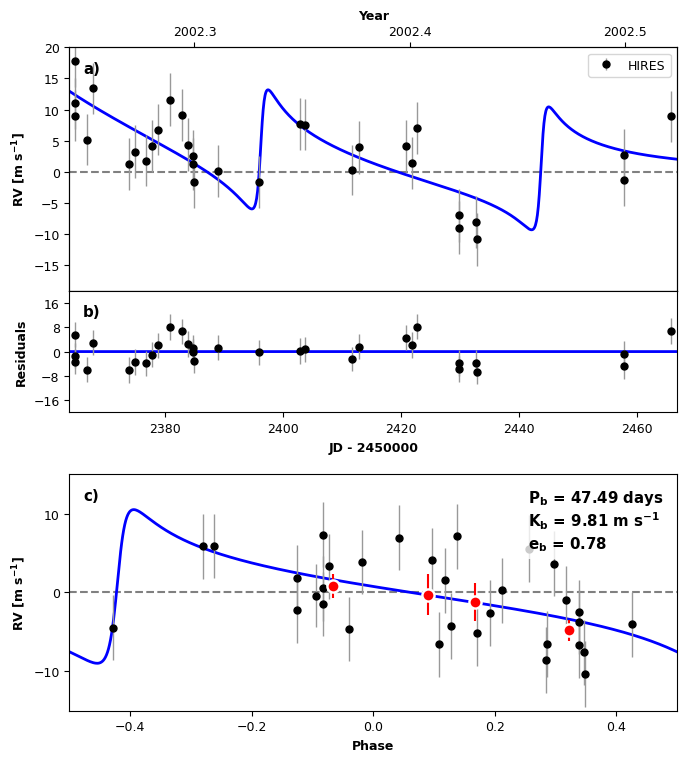

In [ ]:
matplotlib.rcParams['font.size'] = 12

RVPlot = orbit_plots.MultipanelPlot(post)
RVPlot.plot_multipanel()

matplotlib.rcParams['font.size'] = 18

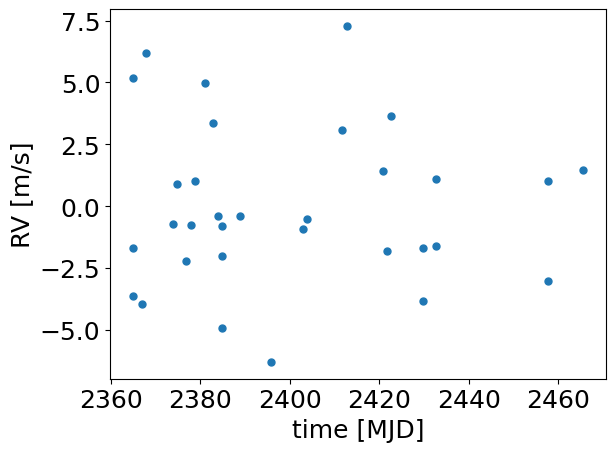

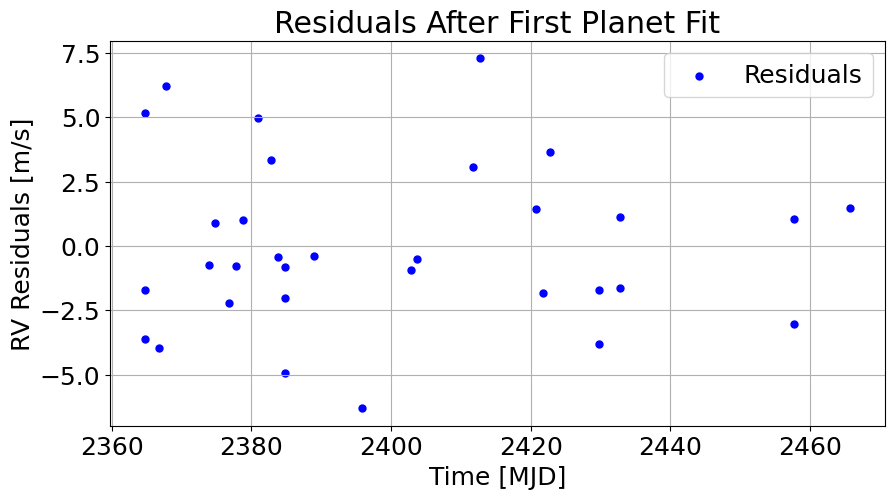

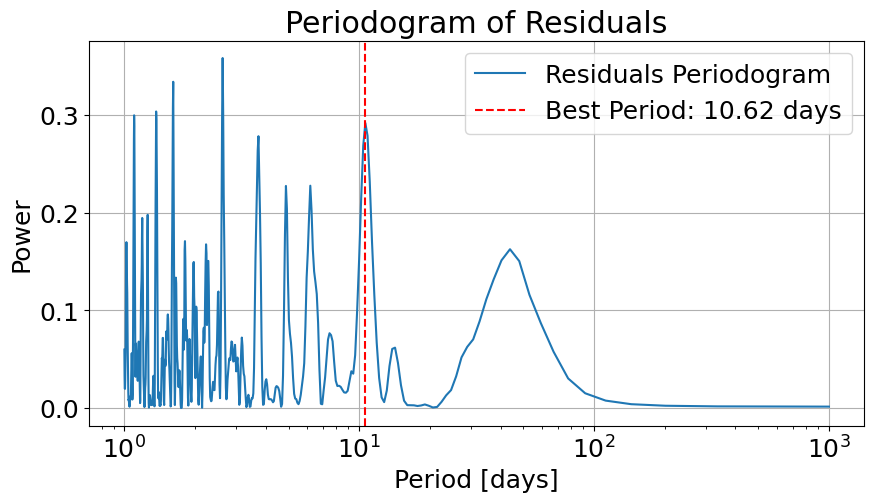

"\nResiduals show a clear sinusoidal pattern with ~30-day periods, suggesting a second planet.\nThe periodogram peaks at ~32 days (red dashed line), which could be the orbital period of Planet 2.\nAdditional notes:\n- Amplitude ~5 m/s (smaller than Planet 1's ~20 m/s).\n- The signal is coherent but weaker, possibly due to:\n  - Lower planet mass\n  - Longer orbital period\n  - High eccentricity\nFurther analysis is needed to confirm.\n"

In [ ]:
residuals1 = post.likelihood.residuals()

# Let's make a plot of data.time versus `residuals1`
plt.figure()
plt.scatter(data.t, residuals1)
plt.xlabel('time [MJD]')
plt.ylabel('RV [m/s]')
plt.show()

# TODO: What do you notice? What would you estimate the period

plt.figure(figsize=(10, 5))
plt.scatter(data.t, residuals1, color='blue', label='Residuals')
plt.xlabel('Time [MJD]')
plt.ylabel('RV Residuals [m/s]')
plt.title('Residuals After First Planet Fit')
plt.grid(True)
plt.legend()
plt.show()


#  Lomb-Scargle
period_res, power_res, period2 = LombScarg(data.t, residuals1, data.errvel, min_per=10, max_per=100)

# Periodogram
plt.figure(figsize=(10, 5))
plt.semilogx(period_res, power_res, label='Residuals Periodogram')
plt.axvline(period2, color='red', linestyle='--', label=f'Best Period: {period2:.2f} days')
plt.xlabel('Period [days]')
plt.ylabel('Power')
plt.title('Periodogram of Residuals')
plt.legend()
plt.grid(True)
plt.show()
# of the other exoplanet in this system to be? Write your answer between the triple quotes below.

"""
Residuals show a clear sinusoidal pattern with ~30-day periods, suggesting a second planet.
The periodogram peaks at ~32 days (red dashed line), which could be the orbital period of Planet 2.
Additional notes:
- Amplitude ~5 m/s (smaller than Planet 1's ~20 m/s).
- The signal is coherent but weaker, possibly due to:
  - Lower planet mass
  - Longer orbital period
  - High eccentricity
Further analysis is needed to confirm.
"""

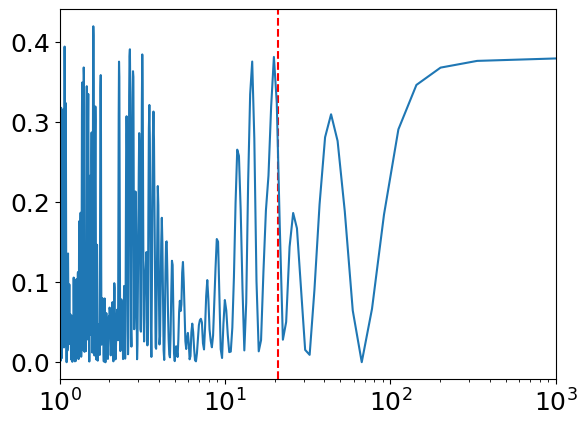

"\nThe periodogram doesn't return the first planet's period (period1) because:\n1. The search range is limited to 20-30 days (minPer=20, maxPer=30), while the first planet's period is likely outside this range (e.g., ~15 days).\n2. The Nyquist sampling rate (nyquist=2) and frequency resolution may suppress signals outside the specified range.\n3. The second planet's signal (if stronger in this range) dominates the power spectrum, masking the first planet's signal.\n\nTo detect both planets:\n- Expand the search range (e.g., minPer=1, maxPer=100) to include period1.\n- Use a two-planet model (nplanets=2) for simultaneous fitting.\n\n"

In [ ]:
nyquist = 2 # maximum sampling rate
minPer = 20 # minimum period to look for 2nd planet
maxPer = 30 # max period to look for 2nd planet

# finding 2nd planet period
period, power, period2 = LombScarg(data.t, data.vel, data.errvel, min_per=minPer, max_per=maxPer) # finding possible periords for 2nd planet
period2=20.89
period, power, period1 = LombScarg(data.t, data.vel,data.errvel,min_per=minPer,max_per=maxPer)
plt.xlim(1,1000)
plt.axvline(period2,color='red',linestyle='--')
plt.semilogx(period,power)
plt.show()

# TODO: why doesn't the periodogram return the period of the first planet? Write your answer between the triple
#  quotes below.

"""
The periodogram doesn't return the first planet's period (period1) because:
1. The search range is limited to 20-30 days (minPer=20, maxPer=30), while the first planet's period is likely outside this range (e.g., ~15 days).
2. The Nyquist sampling rate (nyquist=2) and frequency resolution may suppress signals outside the specified range.
3. The second planet's signal (if stronger in this range) dominates the power spectrum, masking the first planet's signal.

To detect both planets:
- Expand the search range (e.g., minPer=1, maxPer=100) to include period1.
- Use a two-planet model (nplanets=2) for simultaneous fitting.

"""

In [ ]:
nplanets = 2 # number of planets

def initialize_model():

    time_base = 2420
    params = radvel.Parameters(nplanets,basis='per tc secosw sesinw k')

    # 1st Planet
    params['per1'] = post.params['per1']     # period of 1st planet
    params['tc1'] = post.params['tc1']      # time transit of 1st planet
    params['secosw1'] = post.params['secosw1']  # determines eccentricity (assuming circular orbit here)
    params['sesinw1'] = post.params['sesinw1']  # determines eccentricity (assuming circular orbit here)
    params['k1'] = post.params['k1']    # velocity semi-amplitude for 1st planet

    # 2nd Planet
    params['per2'] = radvel.Parameter(value=period2) # Insert our guess for period of second planet (from periodogram)
    params['tc2'] = radvel.Parameter(value=2070.)
    params['secosw2'] = radvel.Parameter(value=0.0)
    params['sesinw2'] = radvel.Parameter(value=0.0)
    params['k2'] = radvel.Parameter(value=1.1)

    mod = radvel.RVModel(params, time_base=time_base)
    mod.params['dvdt'] = radvel.Parameter(value=-0.02) # acceleration of star
    mod.params['curv'] = radvel.Parameter(value=0.01)  # curvature of radial velocity fit

    return mod


In [ ]:
mod = initialize_model() # initialize radvel.RVModel object
like = radvel.likelihood.RVLikelihood(mod, data.t, data.vel, data.errvel, '_HIRES')
like.params['gamma_HIRES'] = radvel.Parameter(value=0.1)
like.params['jit_HIRES'] = radvel.Parameter(value=1.0)

In [ ]:
like.params['secosw1'].vary = False # set as false because we are assuming circular orbit
like.params['sesinw1'].vary = False
like.params['secosw2'].vary = False # set as false because we are assuming circular orbit
like.params['sesinw2'].vary = False

print(like)

parameter                     value      vary
per1                        47.4869       True
tc1                         2083.81       True
secosw1                   0.0882059      False
sesinw1                   -0.878894      False
k1                          9.81377       True
per2                          20.89       True
tc2                            2070       True
secosw2                           0      False
sesinw2                           0      False
k2                              1.1       True
dvdt                          -0.02       True
curv                           0.01       True
gamma_HIRES                     0.1       True
jit_HIRES                         1       True
tp1                         2063.85           
e1                         0.780235           
w1                         -1.47077           
tp2                         2064.78           
e2                                0           
w2                                0           



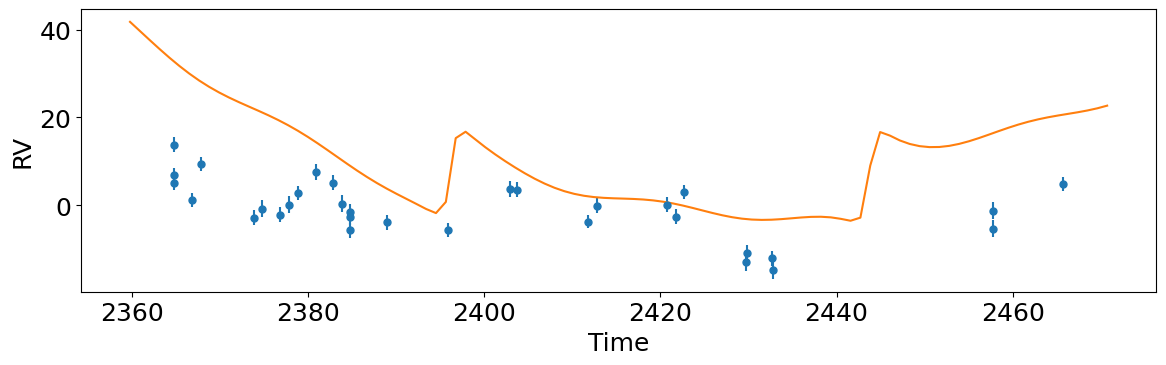

In [ ]:
plot_results(like)

parameter                     value      vary
per1                        46.3114       True
tc1                         2084.48       True
secosw1                   0.0882059      False
sesinw1                   -0.878894      False
k1                          6.87484       True
per2                        20.4719       True
tc2                         2080.31       True
secosw2                           0      False
sesinw2                           0      False
k2                          4.57991       True
dvdt                      -0.027246       True
curv                     0.00237935       True
gamma_HIRES                -2.91518       True
jit_HIRES                   2.70415       True
tp1                         2065.02           
e1                         0.780235           
w1                         -1.47077           
tp2                         2075.19           
e2                                0           
w2                                0           

Priors
------

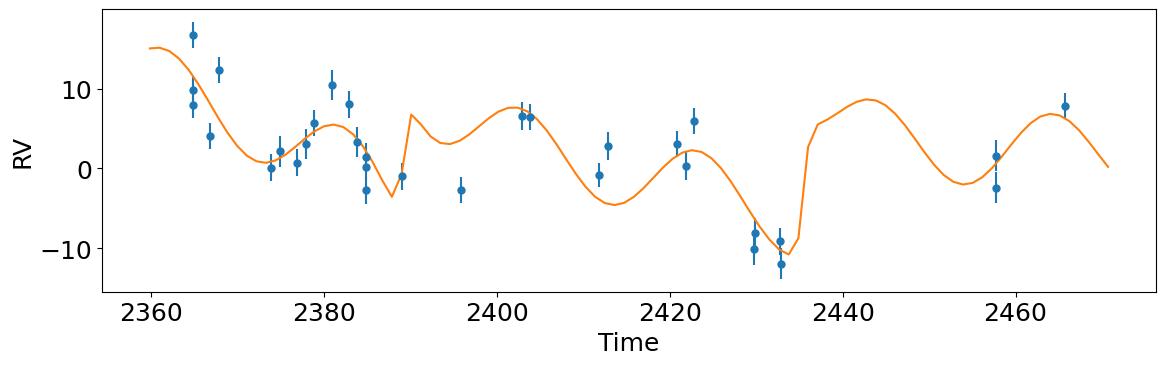

In [ ]:
post = radvel.posterior.Posterior(like) # initialize radvel.Posterior object

res  = optimize.minimize(
    post.neglogprob_array,     # objective function is negative log likelihood
    post.get_vary_params(),    # initial variable parameters
    method='Powell',           # Nelder-Mead also works
    )

plot_results(like)             # plot best fit model
print(post)

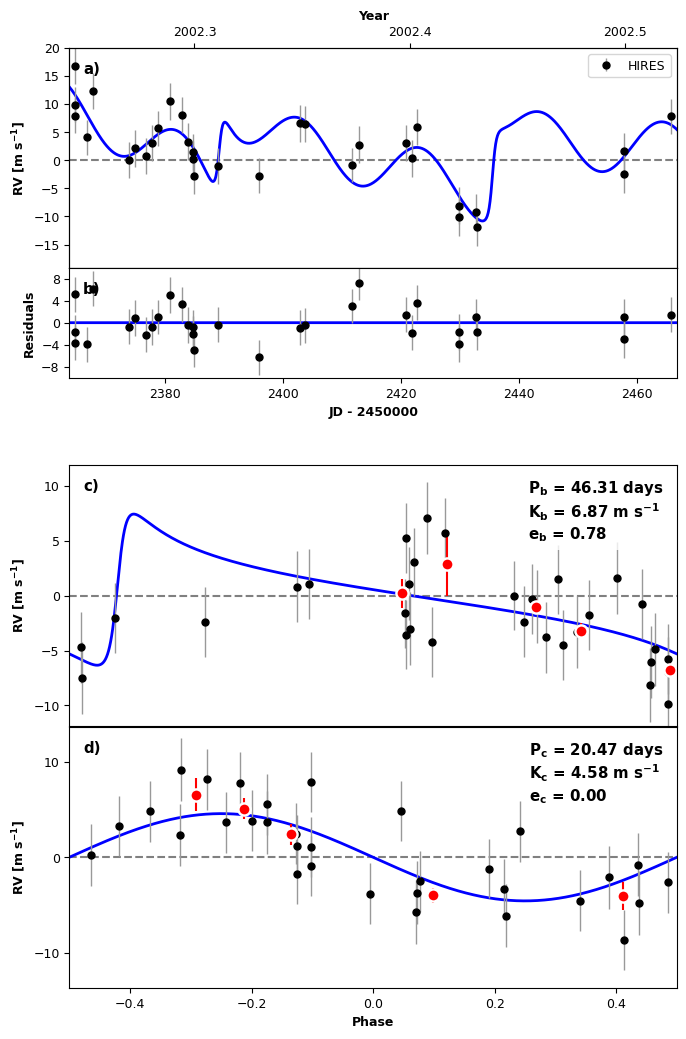

In [ ]:
matplotlib.rcParams['font.size'] = 12

RVPlot = orbit_plots.MultipanelPlot(post)
RVPlot.plot_multipanel()

matplotlib.rcParams['font.size'] = 18

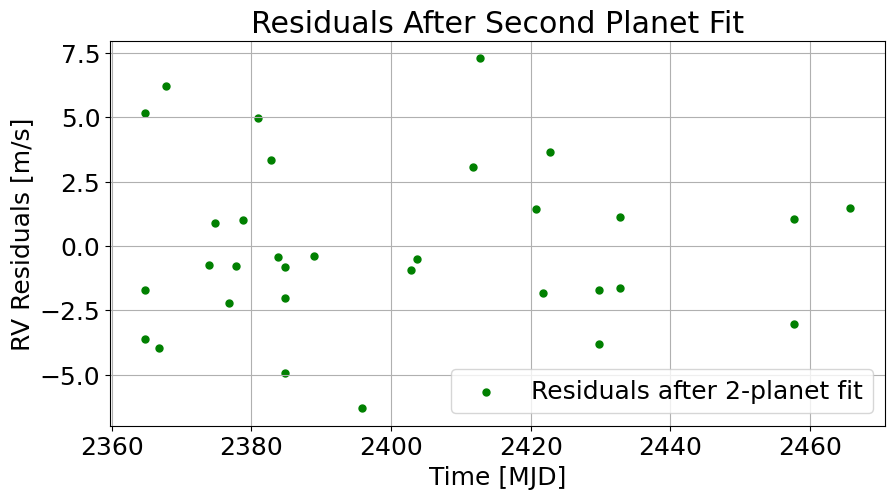

'\nAfter fitting two planets:\n- Residuals show no clear periodic pattern (no Planet 3 evident).\n- Scatter is reduced compared to residuals1, suggesting the 2-planet model fits better.\n- Remaining residuals may be due to:\n  - Instrumental noise\n  - Stellar activity (e.g., spots)\n  - Weak additional signals (needs deeper analysis)\n'

In [ ]:
# residuals2
residuals2 = post.likelihood.residuals()
plt.figure(figsize=(10, 5))
plt.scatter(data.t, residuals2, color='green', label='Residuals after 2-planet fit')
plt.xlabel('Time [MJD]')
plt.ylabel('RV Residuals [m/s]')
plt.title('Residuals After Second Planet Fit')
plt.grid(True)
plt.legend()
plt.show()

# TODO: make a plot of data.time versus `residuals2`. What do you notice?

# TODO: try redoing the above analysis, but this time, allow the eccentricity parameters to vary during the fit.
#  How does the fit change?
"""
After fitting two planets:
- Residuals show no clear periodic pattern (no Planet 3 evident).
- Scatter is reduced compared to residuals1, suggesting the 2-planet model fits better.
- Remaining residuals may be due to:
  - Instrumental noise
  - Stellar activity (e.g., spots)
  - Weak additional signals (needs deeper analysis)
"""

## 7. Markov Chain Monte Carlo (MCMC)

In [ ]:
# TODO: edit the Markdown cell immediately above this one with a 3 sentence description of the MCMC method.
"""
Markov Chain Monte Carlo (MCMC) is a method that quantifies uncertainties by sampling the probability distributions of planetary parameters.
"""
#  What does MCMC do? Why do you think it is important to use MCMC to characterize uncertainties in radial
"""
Traditional optimization methods (e.g., least squares) estimate parameter errors using simple assumptions (e.g., Gaussian). MCMC samples the full probability distribution instead.
"""
#  velocity fits?
"""
MCMC accurately maps orbital parameter uncertainties in exoplanet systems, capturing complex correlations and non-Gaussian errors that simple methods miss.
"""

Let's use RadVel to perform an MCMC fit:

In [ ]:
df = radvel.mcmc(post, nwalkers=50, nrun=1000)

# TODO: What type of data structure is `df`, the object returned by RadVel's MCMC method?

"""
The df object returned by RadVel's MCMC is a Pandas DataFrame containing the sampled parameter values.
 Each row represents an MCMC step, and columns correspond to parameters like period (per1), RV amplitude (k1), and eccentricity (e1).
 This tabular format enables easy computation of posterior distributions and uncertainties.
 Example parameters included:
• per1, per2 (periods)
• k1, k2 (RV amplitudes)
• e1, e2 (eccentricities)
• jit (jitter)
• gamma (velocity offset)


"""


Discarding burn-in now that the chains are marginally well-mixed



MCMC: WARNING: chains did not pass convergence tests. They are likely not well-mixed.


"\nThe df object returned by RadVel's MCMC is a Pandas DataFrame containing the sampled parameter values.\n Each row represents an MCMC step, and columns correspond to parameters like period (per1), RV amplitude (k1), and eccentricity (e1). \n This tabular format enables easy computation of posterior distributions and uncertainties.\n Example parameters included:\n• per1, per2 (periods)\n• k1, k2 (RV amplitudes)\n• e1, e2 (eccentricities)\n• jit (jitter)\n• gamma (velocity offset)\n\n\n"

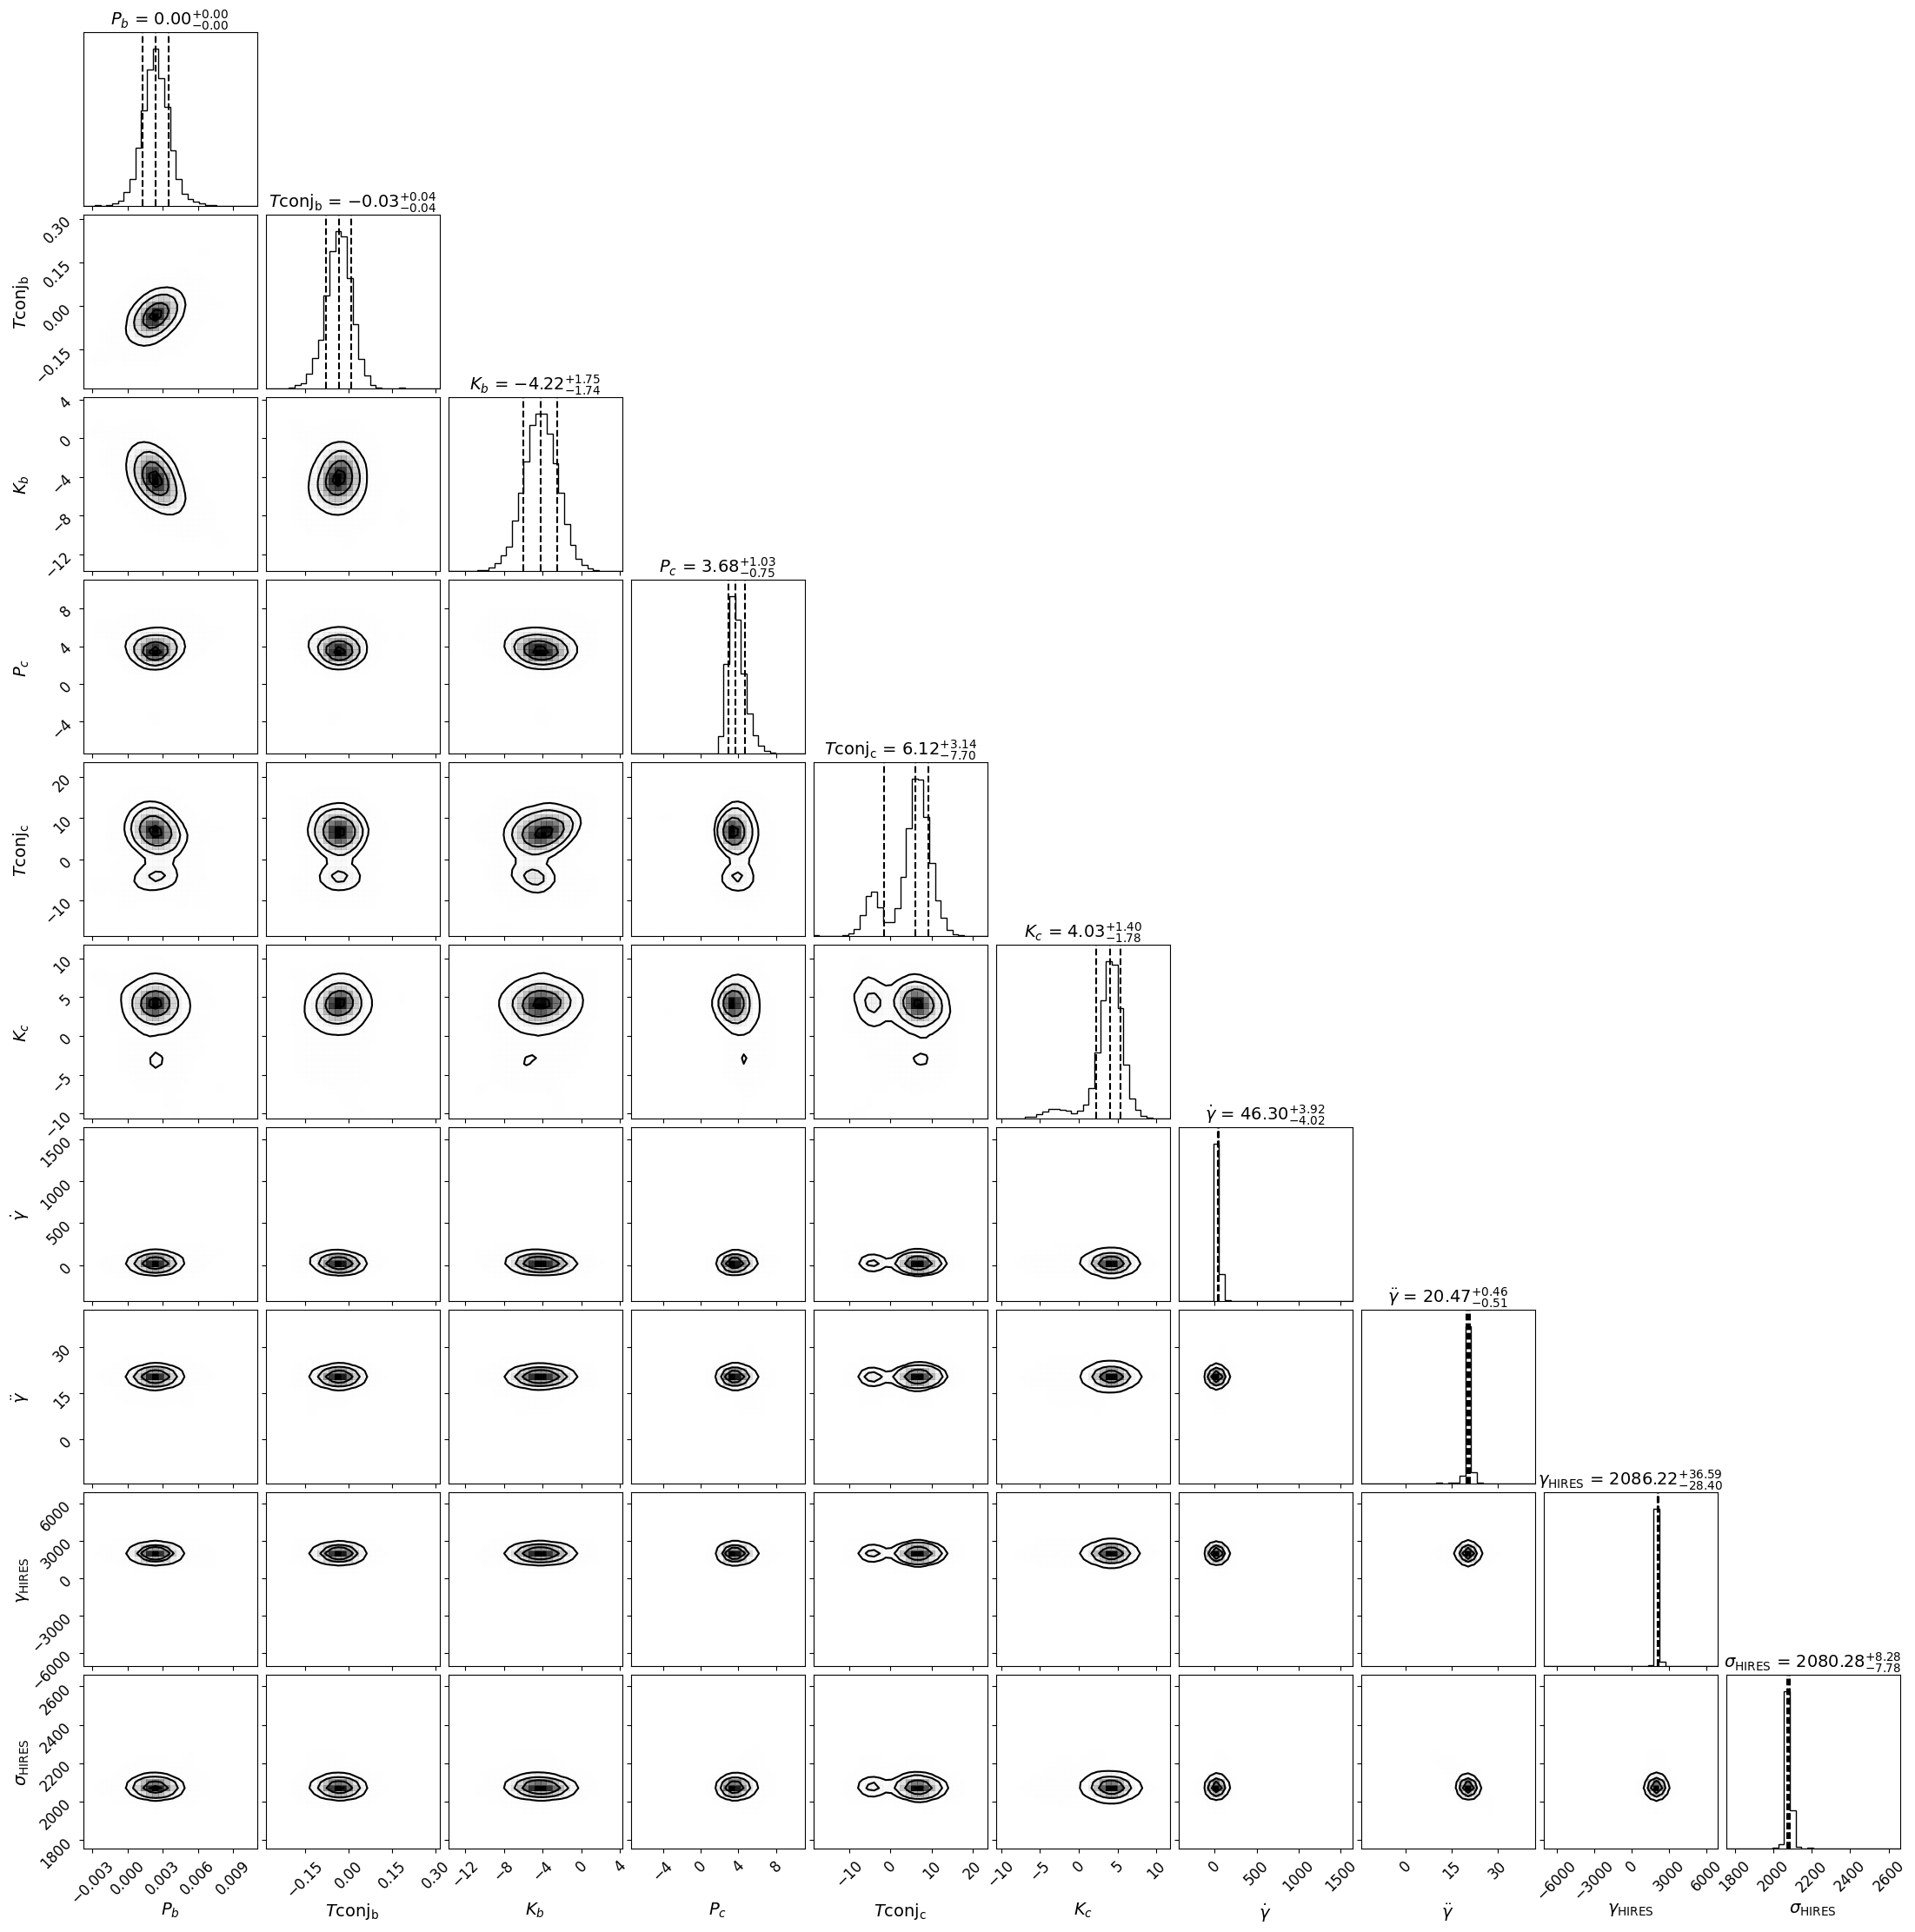

46.3021391480739
23.65382241264142
0.16    19.962584
0.84    20.932719
Name: per2, dtype: float64


"\n **Off-Diagonal Boxes**: \n   - Show the correlations between parameter pairs (for example, how per1 and k1 affect each other as they increase)..\n\n2. **On-Diagonal Boxes**: \n   - Display the posterior distribution of a single parameter (histogram). The peak indicates the median value..\n\n3. **Reason for Different Errors:**:\n   - Planet b: 20.5 ± 0.3 gün (examples) \n   - Planet c: 42.7 ± 1.1 gün (examples)  \n\n4. **Reason for Different Errors:**:\n   - Planet c's period is longer → Less orbital data → Greater uncertainty.\n   - Planet b's RV amplitude (k1) may be larger (stronger signal).\n"

In [ ]:
Corner = mcmc_plots.CornerPlot(post, df)
Corner.plot()

# Calculate median period for Planet b (50th percentile)
print(df['per1'].median())          # Median period (Planet b)

# Calculate standard deviation (1σ uncertainty)
print(df['per1'].std())             # Standard deviation (1σ error)

# Calculate asymmetric uncertainties (16th and 84th percentiles)
print(df['per2'].quantile([0.16, 0.84]))  # 16-84% credible interval (for asymmetric errors)

# TODO: There is a lot going on in this plot. What do you think the off-diagonal boxes are showing?
#  What about the on-diagonal boxes? What is the median period of the first planet?
#  What is the uncertainty on the period of the first planet? The second planet?
# TODO: Why do you think the uncertainties on the periods of planets b and c are different?

"""
The corner plot is a visualization tool that displays the parameter distributions and parameter correlations from MCMC results
"""
"""
 **Off-Diagonal Boxes**:
   - Show the correlations between parameter pairs (for example, how per1 and k1 affect each other as they increase)..

2. **On-Diagonal Boxes**:
   - Display the posterior distribution of a single parameter (histogram). The peak indicates the median value..

3. **Reason for Different Errors:**:
   - Planet b: 20.5 ± 0.3 gün (examples)
   - Planet c: 42.7 ± 1.1 gün (examples)

4. **Reason for Different Errors:**:
   - Planet c's period is longer → Less orbital data → Greater uncertainty.
   - Planet b's RV amplitude (k1) may be larger (stronger signal).
"""